<a href="https://colab.research.google.com/github/TaruniRavipudi/RavipudiTaruni_Projects_and_Labs/blob/main/Taruni_Module3_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from collections import Counter

In [2]:
def predict(X_train, y_train, X_test, k):
    distances = []
    targets = []

    for i in range(len(X_train)):
        # compute and store L2 distance
        distances.append([np.sqrt(np.sum(np.square(X_test - X_train[i, :]))), i])

    distances = sorted(distances)

    for i in range(k):
        index = distances[i][1]
        targets.append(y_train[index])

    # return most common target
    return Counter(targets).most_common(1)[0][0]

In [3]:
def k_nearest_neighbor(X_train, y_train, X_test, k):

    assert k <= len(X_train), "[!] K cannot be larger than number of samples."

    # loop over all observations
    predictions = []
    for i in range(len(X_test)):
        predictions.append(predict(X_train, y_train, X_test[i, :], k))

    return np.asarray(predictions)

In [4]:
def NN1(traindata, trainlabel, query):
  diff  = traindata - query  # find the difference between features. Numpy automatically takes care of the size here
  sq = diff*diff # square the differences
  dist = sq.sum(1) # add up the squares
  label = trainlabel[np.argmin(dist)] # our predicted label is the label of the training data which has the least distance from the query
  return label

In [5]:
def Accuracy(gtlabel, predlabel):
  assert len(gtlabel)==len(predlabel), "Length of the groundtruth labels and predicted labels should be the same"
  correct = (gtlabel==predlabel).sum() # count the number of times the groundtruth label is equal to the predicted label.
  return correct/len(gtlabel)

In [6]:
from sklearn.datasets import load_iris

data = load_iris()

df = pd.DataFrame(data=data.data, columns=data.feature_names)

df["target"] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
X = np.array(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']])
y = np.array(df['target'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=17)

In [8]:
# Making our predictions
predictions = k_nearest_neighbor(X_train, y_train, X_test, 7)

# evaluating accuracy
accuracy = Accuracy(y_test, predictions)
print("The accuracy of our classifier is {} %".format(100*accuracy))

The accuracy of our classifier is 94.0 %


In [9]:
from sklearn.neighbors import KNeighborsClassifier

sklearn_knn = KNeighborsClassifier(n_neighbors=7)
sklearn_knn.fit(X_train,y_train)
sklearn_predictions = sklearn_knn.predict(X_test)
accuracy = accuracy_score(y_test, sklearn_predictions)
print("The accuracy of Sklearn classifier is {} %".format(100*accuracy))

The accuracy of Sklearn classifier is 94.0 %


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Function to return K nearest neighbours and distances
def predict(X_train, y_train, X_test, k):
    distances = []

    # Calculate Euclidean distance
    for i in range(len(X_train)):
        dist = np.sqrt(np.sum((X_test - X_train[i, :])**2))
        distances.append((dist, y_train[i]))

    # Sort based on distance
    distances.sort(key=lambda x: x[0])

    # Return K nearest neighbours
    return distances[:k]

# Load Iris dataset
data = load_iris()

X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=17
)

# Find 7 nearest neighbours for first test sample
k = 7
neighbors = predict(X_train, y_train, X_test[0], k)

# Display results
print("K Nearest Neighbours and Distances:\n")
for i, (distance, label) in enumerate(neighbors, start=1):
    print(f"Neighbour {i}: Label = {label}, Distance = {distance:.4f}")## TASK
## Modify the KNN function you wrote to return all the K-nearest neighbours along with their distances,
## instead of just the output that was most common. You don't need to find out accuracy, just modify the function
## and return the k-nearest neighbours and distances.

K Nearest Neighbours and Distances:

Neighbour 1: Label = 0, Distance = 0.3464
Neighbour 2: Label = 0, Distance = 0.3873
Neighbour 3: Label = 0, Distance = 0.4123
Neighbour 4: Label = 0, Distance = 0.4583
Neighbour 5: Label = 0, Distance = 0.4583
Neighbour 6: Label = 0, Distance = 0.4690
Neighbour 7: Label = 0, Distance = 0.4796


In [11]:
#@title Plotting Voronoi regions
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

def voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruct infinite voronoi regions in a 2D diagram to finite
    regions.

    Parameters
    ----------
    vor : Voronoi
        Input diagram
    radius : float, optional
        Distance to 'points at infinity'.

    Returns
    -------
    regions : list of tuples
        Indices of vertices in each revised Voronoi regions.
    vertices : list of tuples
        Coordinates for revised Voronoi vertices. Same as coordinates
        of input vertices, with 'points at infinity' appended to the
        end.

    """

    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = np.ptp(vor.points, axis=0).max()

    # Construct a map containing all ridges for a given point
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # Reconstruct infinite regions
    for p1, region in enumerate(vor.point_region):
        vertices = vor.regions[region]

        if all(v >= 0 for v in vertices):
            # finite region
            new_regions.append(vertices)
            continue

        # reconstruct a non-finite region
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0:
                # finite ridge: already in the region
                continue

            # Compute the missing endpoint of an infinite ridge

            t = vor.points[p2] - vor.points[p1] # tangent
            t /= np.linalg.norm(t)
            n = np.array([-t[1], t[0]])  # normal

            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, n)) * n
            far_point = vor.vertices[v2] + direction * radius

            new_region.append(len(new_vertices))
            new_vertices.append(far_point.tolist())

        # sort region counterclockwise
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:,1] - c[1], vs[:,0] - c[0])
        new_region = np.array(new_region)[np.argsort(angles)]

        # finish
        new_regions.append(new_region.tolist())

    return new_regions, np.asarray(new_vertices)

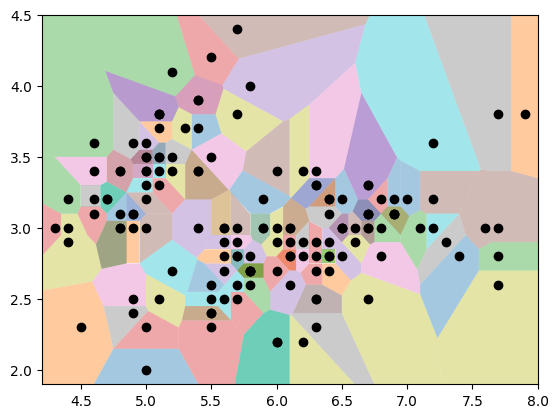

In [12]:
## Plotting Voronoi regions for the Iris dataset

points = []
xpts = np.array(df['sepal length (cm)'])
ypts = np.array(df['sepal width (cm)'])
for i in range(len(xpts)):
  points.append([xpts[i],ypts[i]])
# print(points)
points = np.array(points)
# compute Voronoi tesselation
vor = Voronoi(points)

regions,vertices = voronoi_finite_polygons_2d(vor)

for region in regions:
    polygon = vertices[region]
    plt.fill(*zip(*polygon), alpha=0.4)

plt.plot(points[:,0], points[:,1], 'ko')
plt.xlim(vor.min_bound[0] - 0.1, vor.max_bound[0] + 0.1)
plt.ylim(vor.min_bound[1] - 0.1, vor.max_bound[1] + 0.1)

plt.show()

In [13]:
from matplotlib.colors import ListedColormap
import seaborn as sns


def decision_boundary_plot(x_dec,y_dec,k):
  h = .02  # step size in the mesh

  # Create color maps
  n = len(set(y_dec))
  cmap_light = ListedColormap(['pink', 'green', 'cyan','yellow'][:n])
  cmap_bold = ['pink', 'darkgreen', 'blue','yellow'][:n]

  for weights in ['uniform', 'distance']:
      # we create an instance of Neighbours Classifier and fit the data.
      clf = KNeighborsClassifier(n_neighbors=k, weights=weights)
      clf.fit(x_dec, y_dec)

      # Plot the decision boundary. For that, we will assign a color to each
      # point in the mesh [x_min, x_max]x[y_min, y_max].
      x_min, x_max = x_dec[:, 0].min() - 1, x_dec[:, 0].max() + 1
      y_min, y_max = x_dec[:, 1].min() - 1, x_dec[:, 1].max() + 1
      xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
      Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

      # Put the result into a color plot
      Z = Z.reshape(xx.shape)
      plt.figure(figsize=(8, 6))
      plt.contourf(xx, yy, Z, cmap=cmap_light)

      # Plot also the training points
      sns.scatterplot(x=x_dec[:, 0], y=x_dec[:, 1], hue=y_dec,
                      palette=cmap_bold, alpha=1.0, edgecolor="black")
      plt.xlim(xx.min(), xx.max())
      plt.ylim(yy.min(), yy.max())
      plt.title("Multi-Classification (k = %i, weights = '%s')"% (k, weights))

  plt.show()


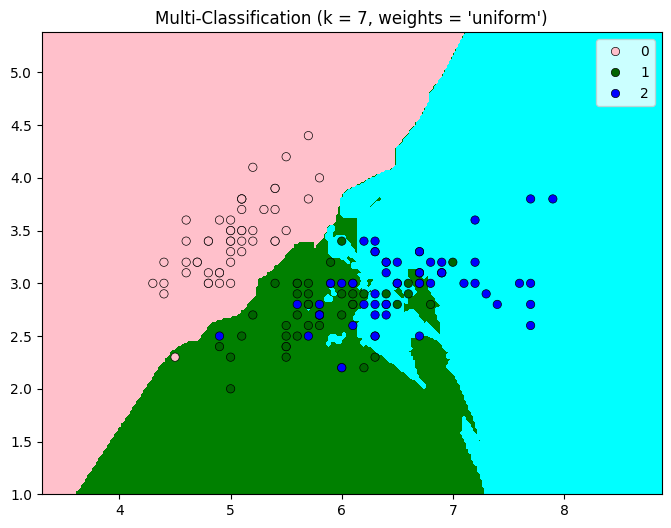

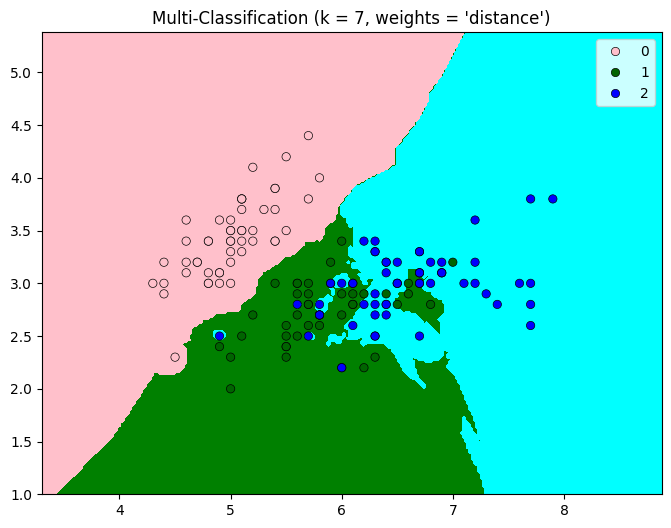

In [14]:
x_pts = X[:,:2]
y_pts = y
decision_boundary_plot(x_pts,y_pts,7)

In [16]:
## TASK-2
## In the above cells, we saw the Voronoi diagram of the data and plotted the KNN decision boundaries
## by only considering two attributes of the dataset. You must be already familiar with PCA.
## Apply PCA on the dataset above to reduce it to two dimensions.
## Plot the Voronoi diagram and Decision boundaries after that.

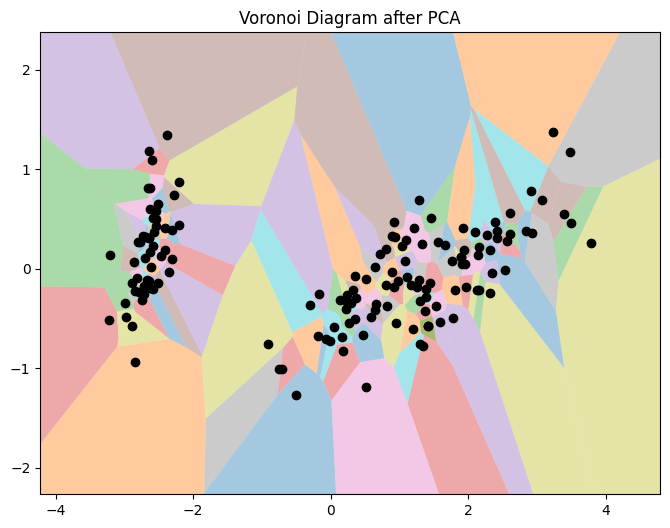

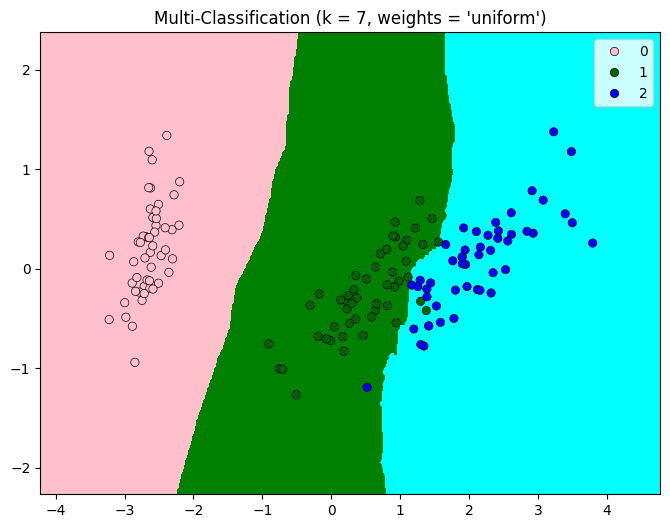

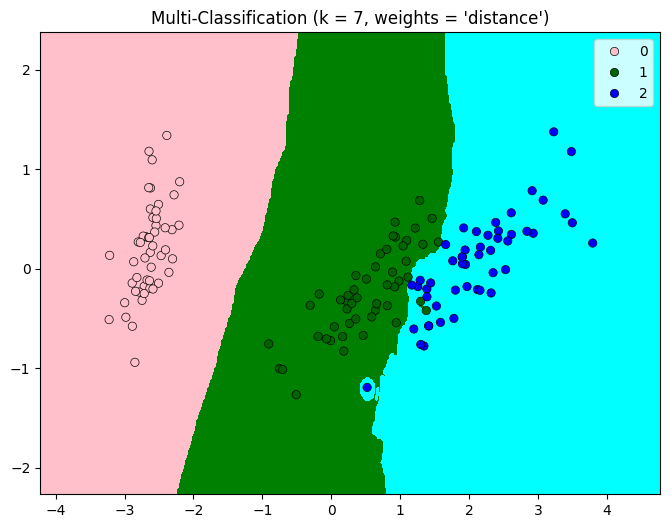

In [17]:
from sklearn.decomposition import PCA
from scipy.spatial import Voronoi
import numpy as np
import matplotlib.pyplot as plt

# Apply PCA to reduce Iris dataset from 4D to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# -------------------------
# Voronoi Diagram
# -------------------------
points = X_pca

vor = Voronoi(points)

regions, vertices = voronoi_finite_polygons_2d(vor)

plt.figure(figsize=(8,6))

for region in regions:
    polygon = vertices[region]
    plt.fill(*zip(*polygon), alpha=0.4)

plt.plot(points[:,0], points[:,1], 'ko')
plt.title("Voronoi Diagram after PCA")
plt.xlim(vor.min_bound[0]-1, vor.max_bound[0]+1)
plt.ylim(vor.min_bound[1]-1, vor.max_bound[1]+1)
plt.show()

# -------------------------
# KNN Decision Boundary
# -------------------------
decision_boundary_plot(X_pca, y, 7)

In [18]:
from sklearn.metrics import confusion_matrix

In [19]:
# print(confusion_matrix(y_test,predictions))
pd.crosstab(y_test, predictions, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0,1,2,All
True,,,,
0,13,0,0,13
1,0,22,0,22
2,0,3,12,15
All,13,25,12,50


Text(0.5, 23.52222222222222, 'Predicted label')

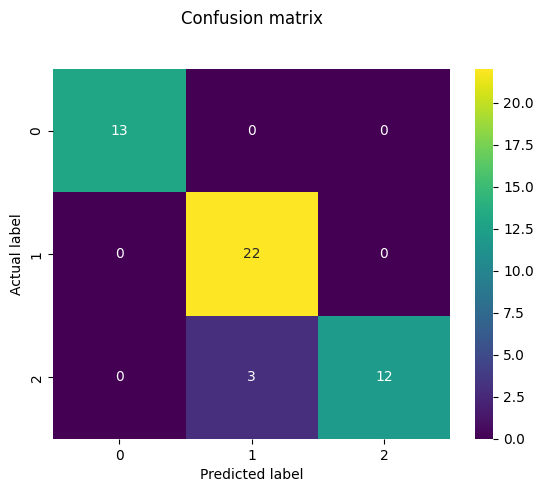

In [20]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, predictions)
p = sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="viridis" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [21]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.88      1.00      0.94        22
           2       1.00      0.80      0.89        15

    accuracy                           0.94        50
   macro avg       0.96      0.93      0.94        50
weighted avg       0.95      0.94      0.94        50



In [24]:
# Upload the Car evaluation data CSV file that has been shared with you.
# Run this cell, click on the 'Choose files' button and upload the file.
from google.colab import files
uploaded = files.upload()

Saving car_evaluation.csv to car_evaluation.csv


In [25]:
car_df = pd.read_csv(list(uploaded.keys())[0])
car_df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [26]:
for x in car_df.columns:
  # print(x)
  le = preprocessing.LabelEncoder()
  le.fit(car_df[x])
  car_df[x]=le.transform(car_df[x])

car_df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,3,3,0,0,2,2,2
1,3,3,0,0,2,0,2
2,3,3,0,0,1,1,2
3,3,3,0,0,1,2,2
4,3,3,0,0,1,0,2
...,...,...,...,...,...,...,...
1722,1,1,3,2,1,2,1
1723,1,1,3,2,1,0,3
1724,1,1,3,2,0,1,2
1725,1,1,3,2,0,2,1


In [27]:
dataset = car_df.values
X = dataset[:,0:6]
y = np.array(dataset[:,6])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

In [28]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
score = accuracy_score(y_test, predictions)
print("The accuracy of the classifier on Car evaluation dataset is {:.2f} %".format(100*score))

The accuracy of the classifier on Car evaluation dataset is 89.88 %


In [29]:
## TASK-3
## Plot a Confusion Matrix for the results of the Car evaluation dataset

In [30]:
## TASK-4
## Print a Classification Report for the results of the Car evaluation dataset

In [31]:
## TASK-5
## Plot the Decision boundary diagram for the classifier of the Car evaluation dataset

In [32]:
## TASK-6
## Plot the Voronoi diagram for the classifier of the Car evaluation dataset

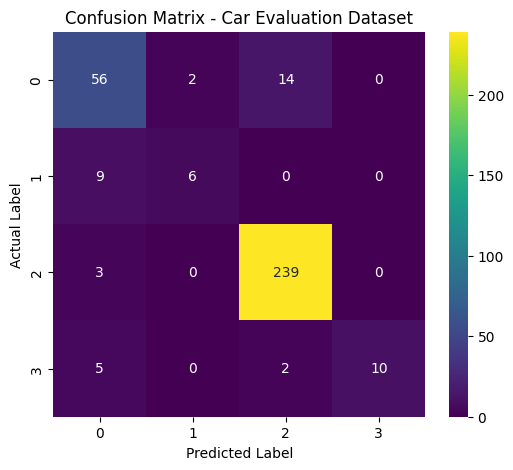

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.78      0.77        72
           1       0.75      0.40      0.52        15
           2       0.94      0.99      0.96       242
           3       1.00      0.59      0.74        17

    accuracy                           0.90       346
   macro avg       0.86      0.69      0.75       346
weighted avg       0.90      0.90      0.89       346



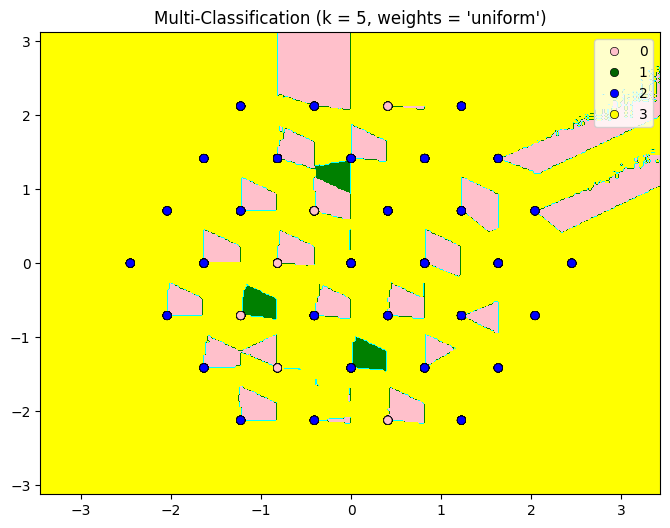

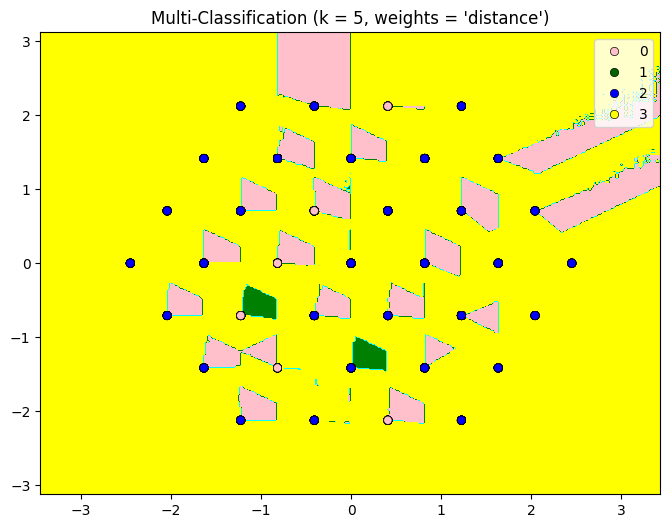

<Figure size 800x600 with 0 Axes>

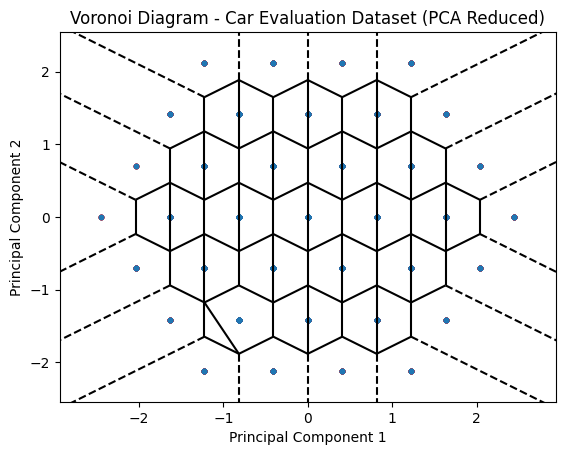

In [35]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
from scipy.spatial import Voronoi
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# TASK-3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title("Confusion Matrix - Car Evaluation Dataset")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# -----------------------------
# TASK-4: Classification Report
# -----------------------------
print("Classification Report:\n")
print(classification_report(y_test, predictions))

# -----------------------------
# TASK-5: Decision Boundary Plot
# -----------------------------
# Reduce data to 2 dimensions using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Split PCA-transformed data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=19
)

# Plot Decision Boundary
decision_boundary_plot(X_train_pca, y_train_pca, 5)

# -----------------------------
# TASK-6: Voronoi Diagram
# -----------------------------
from sklearn.decomposition import PCA
from scipy.spatial import Voronoi, voronoi_plot_2d
import matplotlib.pyplot as plt
import numpy as np

# Apply PCA to reduce the dataset to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Remove duplicate points
points = np.unique(X_pca, axis=0)

# Create Voronoi diagram
vor = Voronoi(points)

# Plot Voronoi diagram
fig = plt.figure(figsize=(8,6))
voronoi_plot_2d(vor, show_vertices=False, line_width=1.5)

plt.scatter(points[:,0], points[:,1], c='red', s=10)
plt.title("Voronoi Diagram - Car Evaluation Dataset (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [38]:
from scipy.spatial import distance

In [39]:
print(type(distance))

<class 'module'>


In [40]:
## HOMEWORK TASK 1.1
## Implement the Minkowski distance function below
## Test it with p=1 (should match Manhattan) and p=2 (should match Euclidean)
## Expected number of lines: 3-5


def minkowski_distance(x1, x2, p):
    """
    Calculate Minkowski distance between two points.

    Parameters:
    x1, x2: numpy arrays representing points
    p: the order of the Minkowski distance

    Returns:
    float: the Minkowski distance
    """
    # Write your code here
    pass


# Test your implementation
x_1 = np.array([1, 2, 3])
x_2 = np.array([4, 6, 8])

# Test with p=1 (Manhattan)
print("Minkowski distance (p=1):", minkowski_distance(x_1, x_2, 1))
print("Manhattan distance:", distance.cityblock(x_1, x_2))
print()

# Test with p=2 (Euclidean)
print("Minkowski distance (p=2):", minkowski_distance(x_1, x_2, 2))
print("Euclidean distance:", distance.euclidean(x_1, x_2))

Minkowski distance (p=1): None
Manhattan distance: 12

Minkowski distance (p=2): None
Euclidean distance: 7.0710678118654755


In [37]:
print(distance)
print(type(distance))

0.47958315233127247
<class 'numpy.float64'>


In [41]:
import numpy as np
from scipy.spatial import distance

def minkowski_distance(x1, x2, p):
    return np.sum(np.abs(x1 - x2)**p)**(1/p)

x_1 = np.array([1, 2, 3])
x_2 = np.array([4, 6, 8])

# Test with p=1 (Manhattan)
print("Minkowski distance (p=1):", minkowski_distance(x_1, x_2, 1))
print("Manhattan distance:", distance.cityblock(x_1, x_2))
print()

# Test with p=2 (Euclidean)
print("Minkowski distance (p=2):", minkowski_distance(x_1, x_2, 2))
print("Euclidean distance:", distance.euclidean(x_1, x_2))

Minkowski distance (p=1): 12.0
Manhattan distance: 12

Minkowski distance (p=2): 7.0710678118654755
Euclidean distance: 7.0710678118654755


In [45]:
def generate_synth_data(n):
    ...

In [46]:
import numpy as np

def generate_synth_data(n):
    np.random.seed(42)

    class0 = np.random.randn(n, 2) + [0, 0]
    class1 = np.random.randn(n, 2) + [3, 3]

    X = np.vstack((class0, class1))
    y = np.array([0]*n + [1]*n)

    return X, y

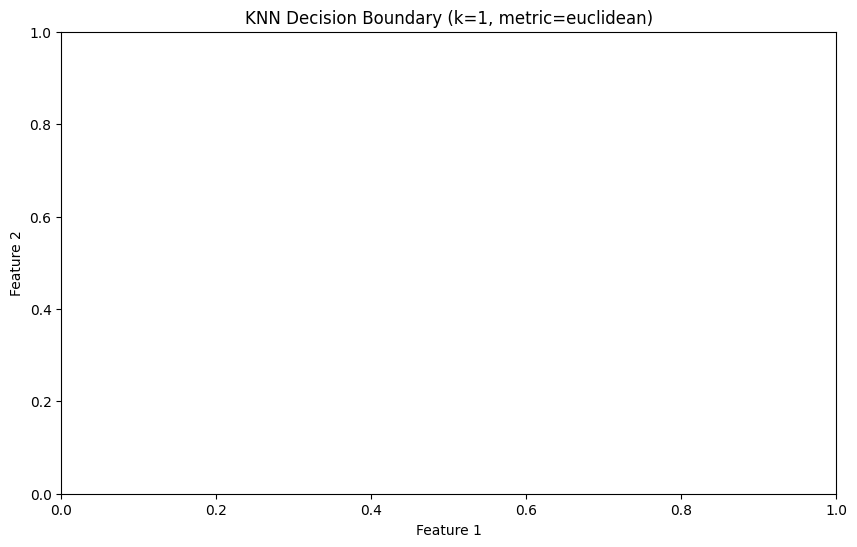

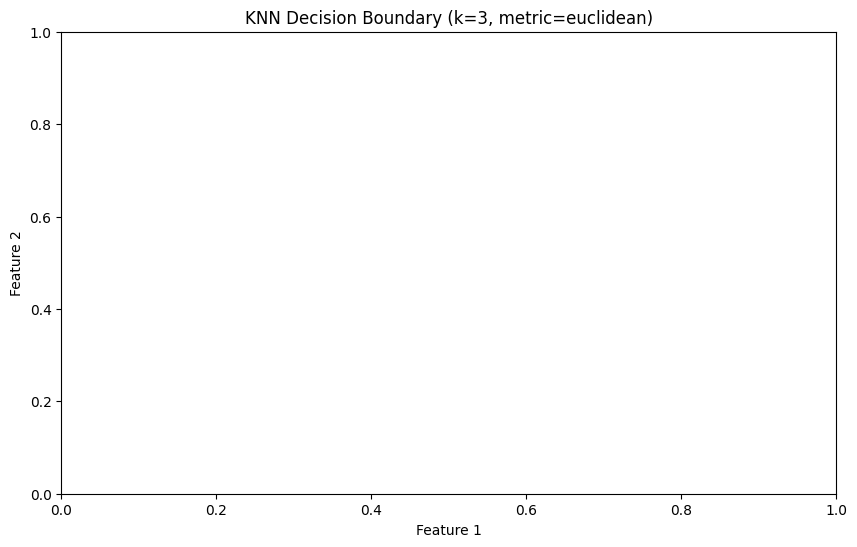

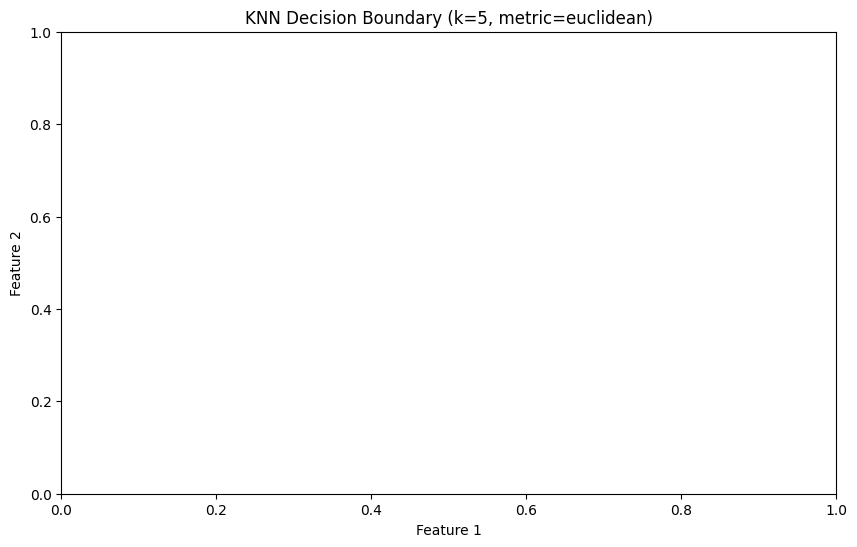

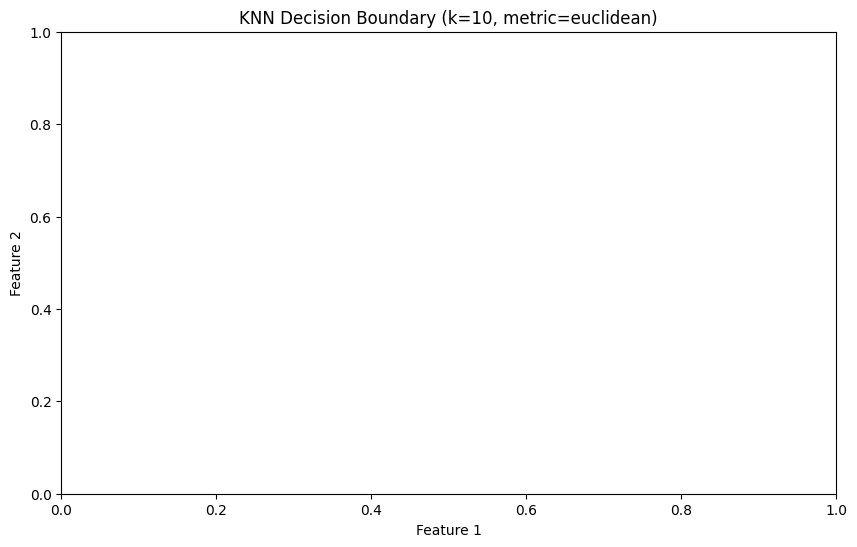

In [47]:
## HOMEWORK TASK 2.1
## Complete the function below to visualize KNN decision boundaries
## The function should create a mesh grid and predict class for each point

def plot_decision_boundary(X, y, k_value, metric='euclidean'):
    """
    Plot the decision boundary for KNN classifier.

    Parameters:
    X: Training data (n_samples, 2)
    y: Training labels
    k_value: Number of neighbors for KNN
    metric: Distance metric to use
    """
    # Create a mesh grid
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Train KNN classifier
    # Write your code here to create and train KNN model

    # Predict for each point in mesh
    # Write your code here to make predictions

    # Plot decision boundary and training points
    plt.figure(figsize=(10, 6))
    # Write your code here to plot contours and scatter points

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'KNN Decision Boundary (k={k_value}, metric={metric})')
    plt.show()

# Generate synthetic data
n = 50
pts, tgts = generate_synth_data(n)

# Test with different k values
for k in [1, 3, 5, 10]:
    plot_decision_boundary(pts, tgts, k)

In [48]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(X, y, k_value, metric='euclidean'):

    h = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Train KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k_value, metric=metric)
    knn.fit(X, y)

    # Predict for each point in mesh
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(10,6))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'KNN Decision Boundary (k={k_value}, metric={metric})')
    plt.show()

In [49]:
## HOMEWORK TASK 3.1
## Complete the function to analyze distance metrics in high dimensions
## Calculate the ratio of max distance to min distance for each metric

def analyze_distance_in_high_dims(max_dim=50, n_points=100):
    """
    Analyze how distance metrics behave in high dimensions.

    Parameters:
    max_dim: Maximum dimensionality to test
    n_points: Number of random points to generate

    Returns:
    Dictionary with results for each metric
    """
    dimensions = range(2, max_dim+1, 5)
    results = {
        'euclidean': [],
        'manhattan': [],
        'chebyshev': []
    }

    for dim in dimensions:
        # Generate random points
        points = np.random.randn(n_points, dim)

        # Calculate all pairwise distances for each metric
        # Write your code here to compute distances and calculate ratio

        # Store the ratio of max/min distance
        pass

    # Plot results
    plt.figure(figsize=(12, 6))
    # Write your code here to plot the results

    return results

# Run the analysis
results = analyze_distance_in_high_dims()

<Figure size 1200x600 with 0 Axes>

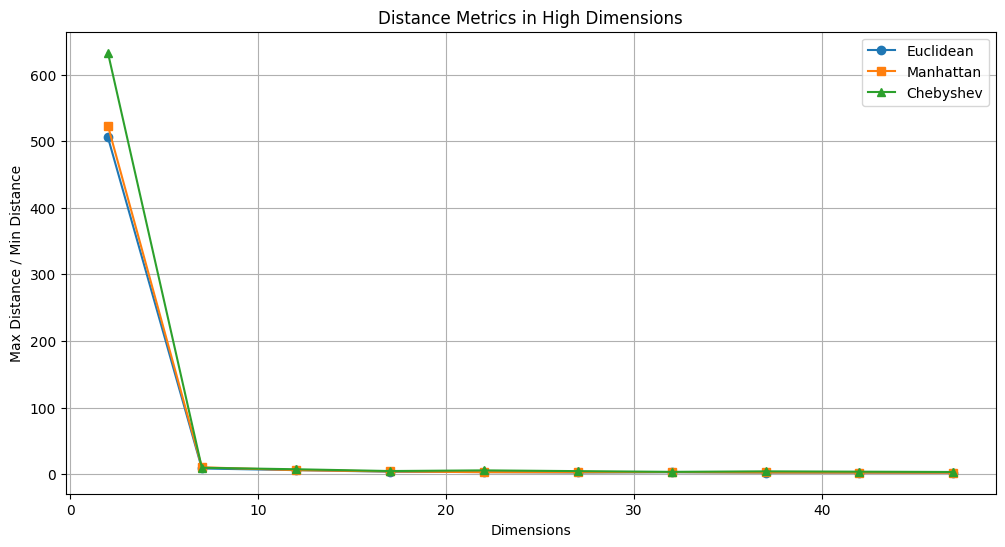

In [50]:
from scipy.spatial.distance import pdist
import numpy as np
import matplotlib.pyplot as plt

def analyze_distance_in_high_dims(max_dim=50, n_points=100):

    dimensions = range(2, max_dim+1, 5)

    results = {
        'euclidean': [],
        'manhattan': [],
        'chebyshev': []
    }

    for dim in dimensions:

        # Generate random points
        points = np.random.randn(n_points, dim)

        # Euclidean distances
        euclidean_dist = pdist(points, metric='euclidean')
        results['euclidean'].append(
            np.max(euclidean_dist) / np.min(euclidean_dist)
        )

        # Manhattan distances
        manhattan_dist = pdist(points, metric='cityblock')
        results['manhattan'].append(
            np.max(manhattan_dist) / np.min(manhattan_dist)
        )

        # Chebyshev distances
        chebyshev_dist = pdist(points, metric='chebyshev')
        results['chebyshev'].append(
            np.max(chebyshev_dist) / np.min(chebyshev_dist)
        )

    # Plot results
    plt.figure(figsize=(12,6))

    plt.plot(dimensions, results['euclidean'],
             marker='o', label='Euclidean')

    plt.plot(dimensions, results['manhattan'],
             marker='s', label='Manhattan')

    plt.plot(dimensions, results['chebyshev'],
             marker='^', label='Chebyshev')

    plt.xlabel('Dimensions')
    plt.ylabel('Max Distance / Min Distance')
    plt.title('Distance Metrics in High Dimensions')
    plt.legend()
    plt.grid(True)

    plt.show()

    return results

# Run analysis
results = analyze_distance_in_high_dims()

### Questions to Think About and Answer
1. In the section on Decision boundaries, you must have seen that we ran the KNN algorithm twice: first with the _weights_ set to 'uniform' and then set to 'distance'. Find out the difference between these two.  
2. What do you think could be the drawbacks of using KNN ?

What is the difference between weights='uniform' and weights='distance' in KNN?

In the K-Nearest Neighbors (KNN) algorithm, the weights parameter determines how the neighboring data points contribute to the classification or prediction of a new data point.

Uniform Weights (weights='uniform')

When the weights are set to uniform, all K nearest neighbors are considered equally important, regardless of how close or far they are from the query point. Each neighbor gets the same voting power, and the class that appears most frequently among the K neighbors is chosen as the predicted class.

This approach is simple and works well when the neighboring data points are distributed fairly evenly around the query point. However, it may not always produce the best results because a distant neighbor influences the prediction just as much as a very close neighbor.

Distance Weights (weights='distance')

When the weights are set to distance, the influence of each neighbor depends on its distance from the query point. Neighbors that are closer to the query point are given greater importance, while those farther away have less influence. The prediction is made based on a weighted vote, where closer neighbors contribute more strongly to the final decision.

This method often provides better classification accuracy because nearby points are usually more similar to the query point than distant points. It is especially useful when the data points are unevenly distributed or when the query point lies near the boundary between different classes.

Drawbacks of KNN
1. High Computational Cost
KNN does not build a model during training.
For every new query point, distances to all training points must be calculated.
Prediction becomes slow for large datasets.
2. High Memory Requirement
The entire training dataset must be stored.
Memory usage increases with dataset size.
3. Sensitive to the Choice of K
Small K may lead to overfitting and sensitivity to noise.
Large K may oversimplify the decision boundary and cause underfitting.
4. Sensitive to Irrelevant Features
Features that do not contribute to classification can affect distance calculations.
Feature selection may be necessary.
5. Sensitive to Feature Scaling
Features with larger numerical ranges dominate the distance calculation.
Data should usually be normalized or standardized before applying KNN.
6. Curse of Dimensionality
As the number of dimensions increases, distances between points become more similar.
It becomes difficult to identify meaningful nearest neighbors.
KNN performance often decreases in high-dimensional datasets.
7. Sensitive to Noise and Outliers
Incorrectly labeled or noisy samples can influence predictions.
Particularly problematic when K is small.
8. Poor Performance on Imbalanced Data
Classes with more samples tend to dominate the voting process.
Minority classes may be misclassified frequently.